In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Single gene-trait association plots

In [33]:
## Single gene-trait association plot
gene_name = 'APOB'
phenotype = 'apolipoprotein_b_int'

In [34]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [35]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet").filter(pl.col('gene_name') == gene_name).collect(engine='streaming')

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
)

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Get gene_id to get olink protein
olink_prot = anno['region'].unique()[0] + '_olink'

anno

zooverphylop,region,esmscoremissense,cadd_raw,am_pathogenicity,gpn_score,id,loftee_hc,promoterai_under,abexp_max,verphylop,Strand,promoterai_abs,promoterai_over,absplice2_max,relative_cds_position,gene_length,pangolin_score,delta_score,dist_to_tss,gene_name,promoterai,abexp_min,absplice_dna_max,TSS
f32,str,f32,f32,f32,f32,str,i8,f32,f64,f32,cat,f32,f32,f32,f32,i64,f32,f32,i64,str,f32,f64,f32,i64
-0.086,"""ENSG00000084674""",0.0,0.38067,0.0,-1.07,"""chr2:21035577:G:A""",0,0.0,0.013533,0.783,"""-""",0.0,0.0,0.000269,0.0,42646,0.0,0.0,8496,"""APOB""",0.0,-0.02242,0.003,21044073
-0.472,"""ENSG00000084674""",0.0,-0.609634,0.0,-1.47,"""chr2:21029016:T:C""",0,0.0,0.002469,-1.513,"""-""",0.0,0.0,0.000033,0.0,42646,0.0,0.0,15057,"""APOB""",0.0,-0.019552,0.001,21044073
-0.778,"""ENSG00000084674""",0.0,0.114383,0.0,0.06,"""chr2:21042116:G:C""",0,0.0,0.002372,0.24,"""-""",0.0,0.0,0.000033,0.0,42646,0.0,0.0,1957,"""APOB""",0.0,-0.019649,0.001,21044073
-1.327,"""ENSG00000084674""",0.0,-0.089471,0.0,-0.28,"""chr2:21036905:C:A""",0,0.0,0.002469,-0.612,"""-""",0.0,0.0,0.000033,0.0,42646,0.0,0.0,7168,"""APOB""",0.0,-0.019552,0.001,21044073
1.407,"""ENSG00000084674""",0.0,0.820982,0.0,-2.17,"""chr2:21044070:G:T""",0,-0.0102,-0.019457,0.754,"""-""",0.0102,0.0,0.000033,0.0,42646,0.0,0.0,3,"""APOB""",-0.0102,-0.036167,0.001,21044073
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.146,"""ENSG00000084674""",0.0,0.172984,0.0,-1.46,"""chr2:20998187:TATC:T""",0,0.0,null,0.042,"""-""",0.0,0.0,0.0,0.0,42646,0.0,0.0,45886,"""APOB""",0.0,null,0.0,21044073
-0.146,"""ENSG00000084674""",0.0,0.59094,0.0,-1.46,"""chr2:21042977:TGAA:T""",0,0.0,null,0.042,"""-""",0.0,0.0,0.0,0.0,42646,0.0,0.0,1096,"""APOB""",0.0,null,0.0,21044073
-0.146,"""ENSG00000084674""",0.0,0.0,0.0,-1.46,"""chr2:21027306:A:ATTTTTTTTTTTTT…",0,0.0,null,0.042,"""-""",0.0,0.0,0.0,0.0,42646,0.0,0.0,16767,"""APOB""",0.0,null,0.0,21044073


In [36]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr2:21035577:G:A""","""ENSG00000084674""","""loftee_hc""",0.0
"""chr2:21029016:T:C""","""ENSG00000084674""","""loftee_hc""",0.0
"""chr2:21042116:G:C""","""ENSG00000084674""","""loftee_hc""",0.0
"""chr2:21036905:C:A""","""ENSG00000084674""","""loftee_hc""",0.0
"""chr2:21044070:G:T""","""ENSG00000084674""","""loftee_hc""",0.0
…,…,…,…
"""chr2:20998187:TATC:T""","""ENSG00000084674""","""abexp_max""",null
"""chr2:21042977:TGAA:T""","""ENSG00000084674""","""abexp_max""",null
"""chr2:21027306:A:ATTTTTTTTTTTTT…","""ENSG00000084674""","""abexp_max""",null


In [37]:
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

olink_appv = (
    olink_appv
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
    })
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('olink_prot') == olink_prot)
    )
)

olink_appv.head().collect()

id,olink_prot,n_individuals,mean_olink_value,std_pheno_value
str,str,u64,f32,f32
"""chr2:21026851:A:G""","""ENSG00000084674_olink""",1,-0.403662,null
"""chr2:21000891:GTAATTATAAACATTT…","""ENSG00000084674_olink""",400,0.052173,1.009272
"""chr2:21009934:C:A""","""ENSG00000084674_olink""",1,-0.273754,null
"""chr2:21000921:GTAATTATAAACATTT…","""ENSG00000084674_olink""",140,0.063767,1.000626
"""chr2:21029445:C:T""","""ENSG00000084674_olink""",18,0.045191,0.776104


In [38]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('phenotype') == phenotype)
    )
)

appv.head().collect()

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr2:21001306:C:T""","""apolipoprotein_b_int""",10,-0.470922,0.928092
"""chr2:21000932:C:T""","""apolipoprotein_b_int""",393,-0.103709,0.908392
"""chr2:20998306:G:T""","""apolipoprotein_b_int""",10,-0.372142,1.158457
"""chr2:21007784:C:T""","""apolipoprotein_b_int""",4,-0.373252,0.760105
"""chr2:21001082:T:C""","""apolipoprotein_b_int""",332,0.19487,1.002875


In [39]:
# Merge olink, phenotype, and annotation data
pg_df = (
    olink_appv
    .join(
        appv,
        on="id",
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on="id",
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(),
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

# Join with experimental data
# pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,olink_prot,n_individuals,mean_olink_value,std_pheno_value,phenotype,n_individuals_right,mean_pheno_value,std_pheno_value_right,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,u32,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr2:21036480:A:G""","""ENSG00000084674_olink""",4,-0.774714,1.368114,"""apolipoprotein_b_int""",26,-0.538137,0.814388,"""ENSG00000084674""","""delta_score""",0.0,21044073,"""-""",42646,"""APOB""",7593
"""chr2:21004369:C:T""","""ENSG00000084674_olink""",2,-0.582226,0.07986,"""apolipoprotein_b_int""",38,-0.022233,0.81726,"""ENSG00000084674""","""delta_score""",0.0,21044073,"""-""",42646,"""APOB""",39704
"""chr2:21041621:G:A""","""ENSG00000084674_olink""",2,-1.542401,null,"""apolipoprotein_b_int""",6,0.463089,0.609928,"""ENSG00000084674""","""delta_score""",0.0,21044073,"""-""",42646,"""APOB""",2452
"""chr2:21043700:C:T""","""ENSG00000084674_olink""",1,0.646161,null,"""apolipoprotein_b_int""",1,-0.519006,null,"""ENSG00000084674""","""delta_score""",0.0,21044073,"""-""",42646,"""APOB""",373
"""chr2:21014955:T:C""","""ENSG00000084674_olink""",1,0.280766,null,"""apolipoprotein_b_int""",11,0.178768,1.217704,"""ENSG00000084674""","""delta_score""",0.0,21044073,"""-""",42646,"""APOB""",29118
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:21019109:C:G""","""ENSG00000084674_olink""",2,0.661667,null,"""apolipoprotein_b_int""",6,0.122336,0.956326,"""ENSG00000084674""","""abexp_max""",-0.003085,21044073,"""-""",42646,"""APOB""",24964
"""chr2:21022164:G:T""","""ENSG00000084674_olink""",2,0.462343,0.306846,"""apolipoprotein_b_int""",11,-0.138923,0.504729,"""ENSG00000084674""","""abexp_max""",0.006871,21044073,"""-""",42646,"""APOB""",21909
"""chr2:21029612:T:C""","""ENSG00000084674_olink""",1,-1.220476,null,"""apolipoprotein_b_int""",1,0.392142,null,"""ENSG00000084674""","""abexp_max""",0.011339,21044073,"""-""",42646,"""APOB""",14461


In [40]:
pg_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""delta_score""",3919
"""absplice_dna_max""",3919
"""gpn_score""",3919
"""zooverphylop""",3919
"""verphylop""",3919
…,…
"""esmscoremissense""",3919
"""promoterai""",3919
"""promoterai_over""",3919


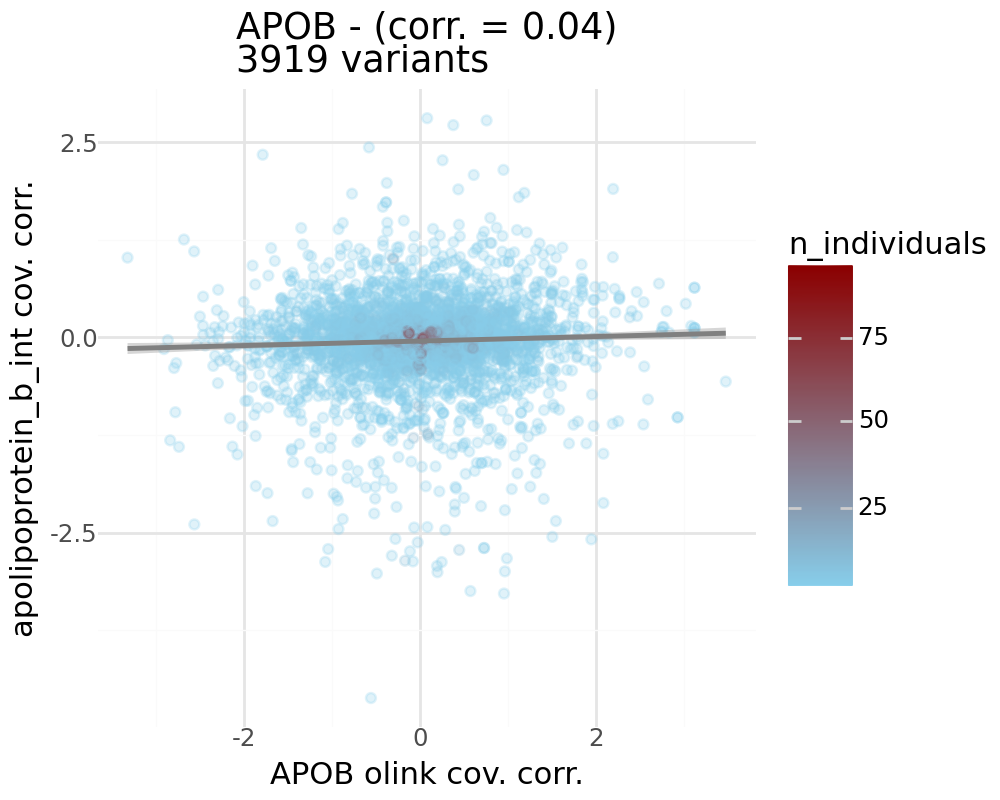

In [41]:
plot_df = pg_df[['id', 'mean_olink_value', 'mean_pheno_value', 'n_individuals']].unique()

(
    ggplot(plot_df, aes(x='mean_olink_value', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{gene_name} olink cov. corr.",
        y=f"{phenotype} cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('mean_olink_value', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

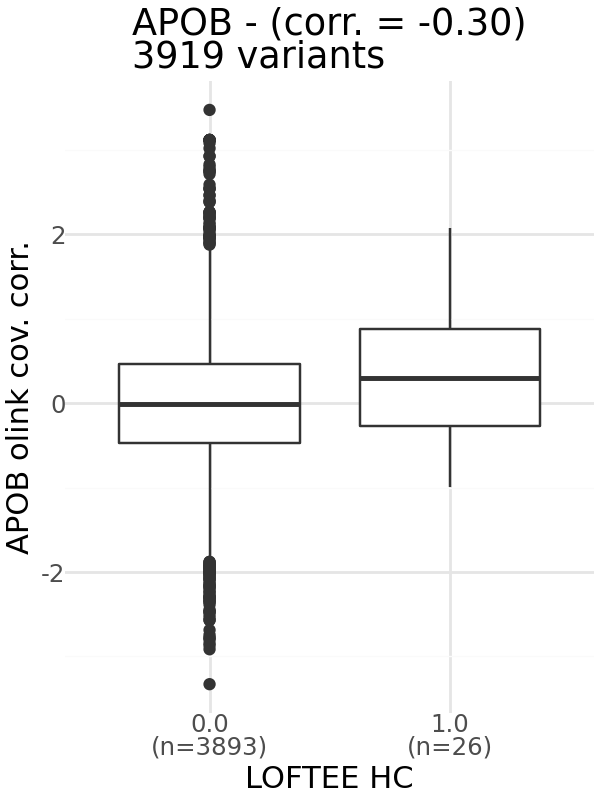

In [54]:
annotation = 'loftee_hc'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

summary_labels = (
    plot_df
    .group_by(['annotation_score'])
    .agg(n_vars = pl.col('id').len())
    .with_columns(n_label = pl.col('annotation_score').cast(pl.Utf8) + '\n(n=' + pl.col('n_vars').cast(pl.Utf8) + ')')
)

plot_df = plot_df.join(summary_labels, on='annotation_score', how='left')

(
    ggplot(plot_df, aes(x='n_label', y='mean_olink_value')) +
    geom_boxplot(aes(group='n_label')) +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(3, 4))
)

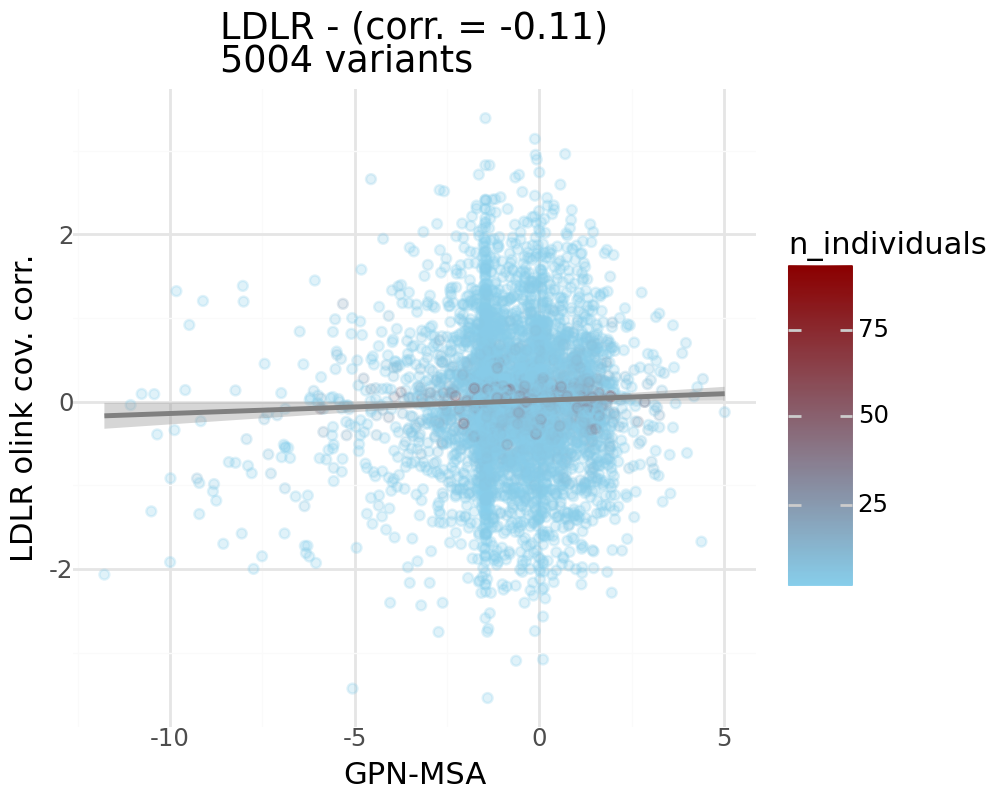

In [16]:
annotation = 'gpn_score'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)